# CBAM 리스크 분석 — 보고서 시각화

**입력 파일**
- `../csv/processed/C123_scaled_master_table.csv` — 스케일링 단계별 분포
- `../csv/processed/CBAM_Final_Risk_Analysis_2026.csv` — 등급·요인 분석

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import platform
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
else:
    fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
    plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

BG = '#F8F9FA'
grade_colors  = {'RED': '#C0392B', 'YELLOW': '#E67E22', 'GREEN': '#27AE60'}
factor_colors = {'잠재 부담액(C1)': '#C0392B', '수출 의존도(C2)': '#2980B9', '탄소 격차(C3)': '#8E44AD'}

# 데이터 로드
scaled = pd.read_csv('../csv/processed/C123_scaled_master_table.csv', dtype={'hs6': str})
final  = pd.read_csv('../csv/processed/CBAM_Final_Risk_Analysis_2026.csv', dtype={'hs6': str})
red    = final[final['Risk_Grade'] == 'RED'].sort_values('Risk_Score', ascending=False).reset_index(drop=True)

print(f'scaled: {len(scaled):,}행 | final: {len(final)}개 | RED: {len(red)}개')

scaled: 1,238행 | final: 158개 | RED: 32개


---
## 1. 스케일링 단계별 C1/C2/C3 분포 변화

원본 → Robust Scaler → Quantile Transformer(normal) 3단계 분포를 비교합니다.

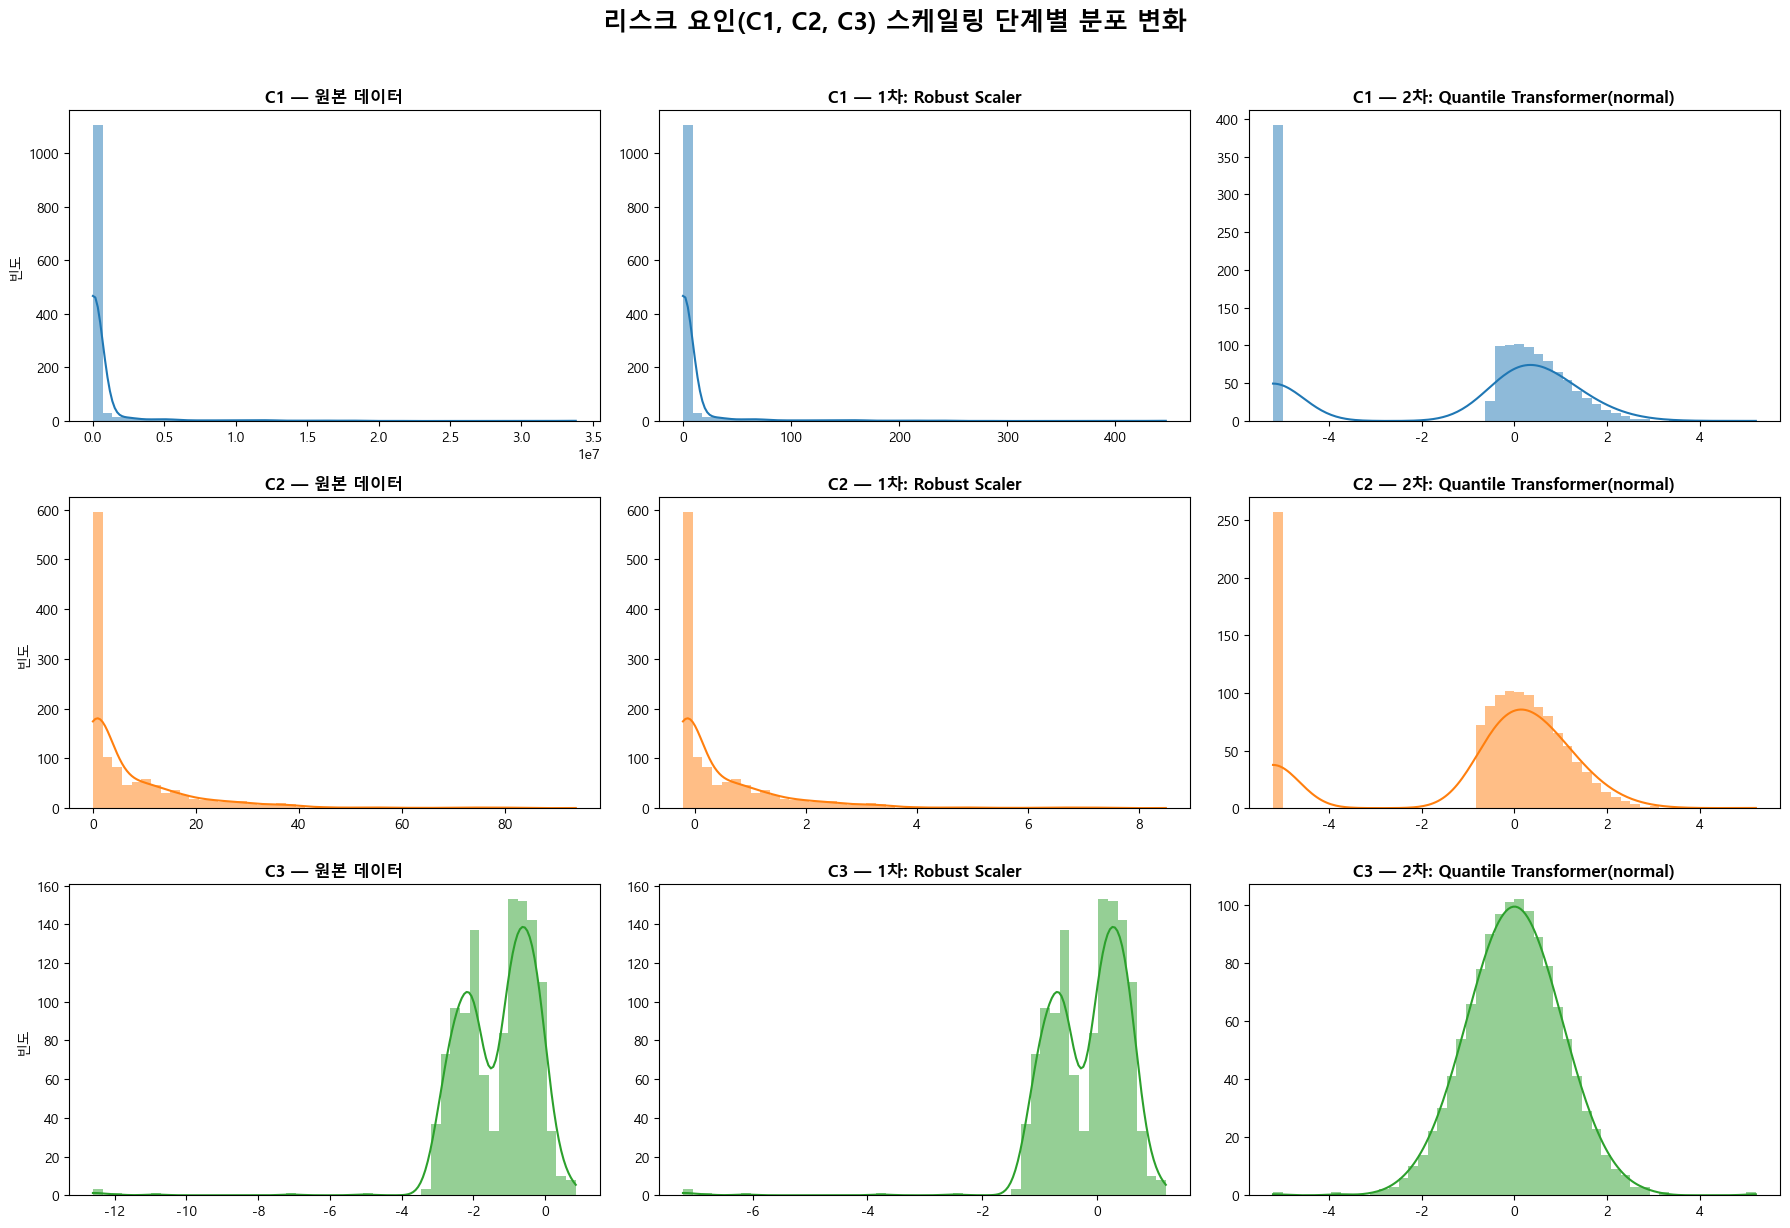

저장: fig_scaling_dist.png


In [2]:
from sklearn.preprocessing import RobustScaler, QuantileTransformer

features = ['c1', 'c2', 'c3']
data = scaled[features].dropna().copy()

robust_scaler = RobustScaler()
robust_df = pd.DataFrame(robust_scaler.fit_transform(data), columns=features)

qt = QuantileTransformer(output_distribution='normal', random_state=42)
final_df = pd.DataFrame(qt.fit_transform(robust_df), columns=features)

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
fig.suptitle('리스크 요인(C1, C2, C3) 스케일링 단계별 분포 변화', fontsize=18, fontweight='bold', y=1.02)

step_names = ['원본 데이터', '1차: Robust Scaler', '2차: Quantile Transformer(normal)']
dfs    = [data, robust_df, final_df]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for i, feature in enumerate(features):
    for j in range(3):
        sns.histplot(dfs[j][feature], kde=True, ax=axes[i, j],
                     color=colors[i], bins=50, alpha=0.5, edgecolor=None)
        axes[i, j].set_title(f'{feature.upper()} — {step_names[j]}', fontsize=12, fontweight='bold')
        axes[i, j].set_ylabel('빈도' if j == 0 else '')
        axes[i, j].set_xlabel('')

plt.tight_layout()
plt.savefig('../csv/processed/fig_scaling_dist.png', dpi=160, bbox_inches='tight')
plt.show()
print('저장: fig_scaling_dist.png')

---
## 2. Risk Score 분포 및 경험적 등급 분할

상위 20% = RED, 상위 50% = YELLOW, 하위 50% = GREEN

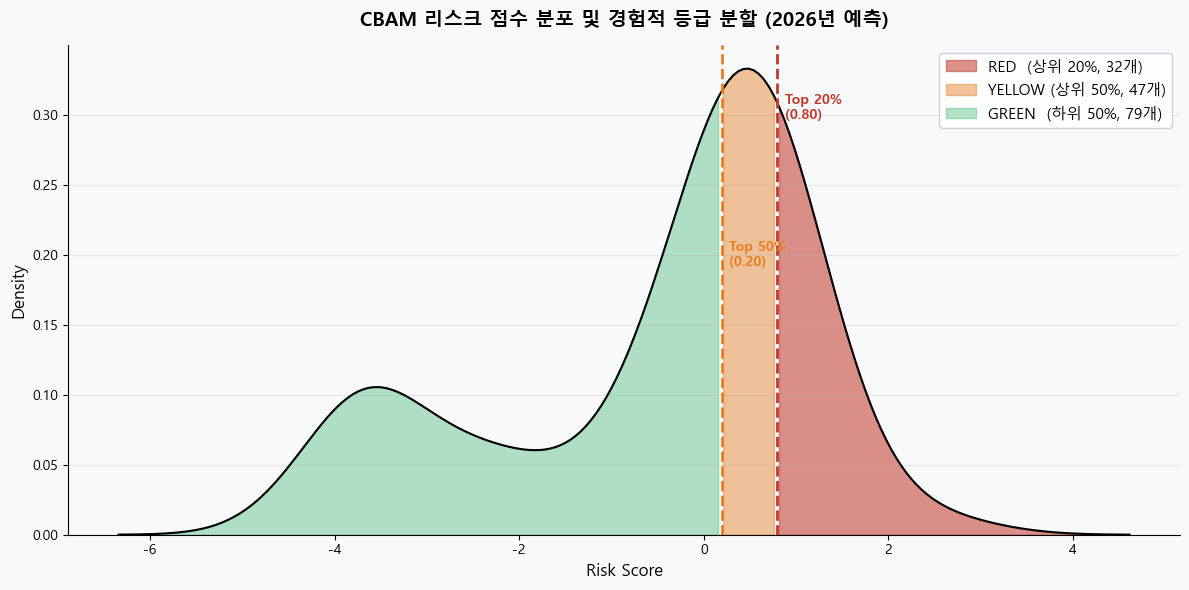

저장: fig_risk_kde.png


In [3]:
thresh_red    = np.percentile(final['Risk_Score'], 80)
thresh_yellow = np.percentile(final['Risk_Score'], 50)

# KDE
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(BG); ax.set_facecolor(BG)

sns.kdeplot(final['Risk_Score'], color='black', linewidth=1.5, fill=False, ax=ax)
x, y = ax.get_lines()[0].get_data()

ax.fill_between(x, y, where=(x >= thresh_red),
                color='#C0392B', alpha=0.55, label=f'RED  (상위 20%, {(final["Risk_Grade"]=="RED").sum()}개)')
ax.fill_between(x, y, where=((x >= thresh_yellow) & (x < thresh_red)),
                color='#E67E22', alpha=0.45, label=f'YELLOW (상위 50%, {(final["Risk_Grade"]=="YELLOW").sum()}개)')
ax.fill_between(x, y, where=(x < thresh_yellow),
                color='#27AE60', alpha=0.35, label=f'GREEN  (하위 50%, {(final["Risk_Grade"]=="GREEN").sum()}개)')

ax.axvline(thresh_red,    color='#C0392B', linestyle='--', linewidth=2)
ax.axvline(thresh_yellow, color='#E67E22', linestyle='--', linewidth=2)
ax.text(thresh_red    + 0.08, ax.get_ylim()[1]*0.85, f'Top 20%\n({thresh_red:.2f})',    color='#C0392B', fontsize=10, fontweight='bold')
ax.text(thresh_yellow + 0.08, ax.get_ylim()[1]*0.55, f'Top 50%\n({thresh_yellow:.2f})', color='#E67E22', fontsize=10, fontweight='bold')

ax.set_title('CBAM 리스크 점수 분포 및 경험적 등급 분할 (2026년 예측)', fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Risk Score', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.legend(fontsize=11, framealpha=0.9)
ax.grid(axis='y', alpha=0.25)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../csv/processed/fig_risk_kde.png', dpi=160, bbox_inches='tight')
plt.show()
print('저장: fig_risk_kde.png')

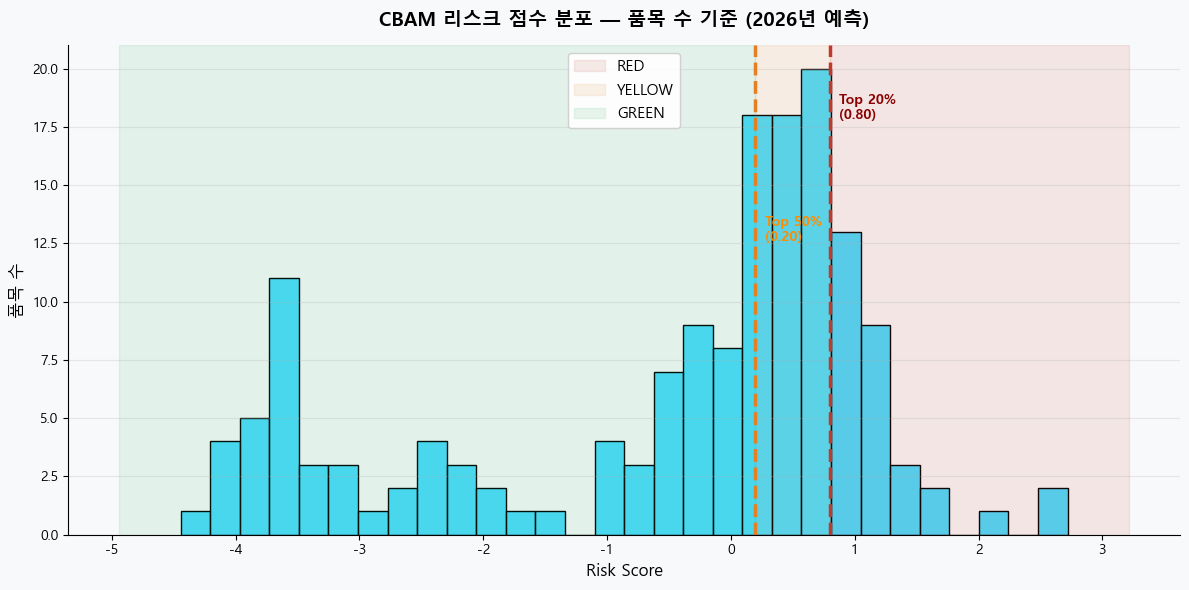

저장: fig_risk_hist.png


In [4]:
# 히스토그램
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(BG); ax.set_facecolor(BG)

sns.histplot(final['Risk_Score'], bins=30, color='#03d1ff', edgecolor='black', alpha=0.7, ax=ax)

ax.axvspan(thresh_red,                     final['Risk_Score'].max() + 0.5, color='#C0392B', alpha=0.1, label='RED')
ax.axvspan(thresh_yellow, thresh_red,                                        color='#E67E22', alpha=0.1, label='YELLOW')
ax.axvspan(final['Risk_Score'].min() - 0.5, thresh_yellow,                  color='#27AE60', alpha=0.1, label='GREEN')

ax.axvline(thresh_red,    color='#C0392B', linestyle='--', linewidth=2.5)
ax.axvline(thresh_yellow, color='#E67E22', linestyle='--', linewidth=2.5)
ax.text(thresh_red    + 0.08, ax.get_ylim()[1]*0.85, f'Top 20%\n({thresh_red:.2f})',    color='darkred',   fontsize=10, fontweight='bold')
ax.text(thresh_yellow + 0.08, ax.get_ylim()[1]*0.60, f'Top 50%\n({thresh_yellow:.2f})', color='darkorange', fontsize=10, fontweight='bold')

ax.set_title('CBAM 리스크 점수 분포 — 품목 수 기준 (2026년 예측)', fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Risk Score', fontsize=12)
ax.set_ylabel('품목 수', fontsize=12)
ax.legend(fontsize=11, framealpha=0.9)
ax.grid(axis='y', alpha=0.25)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../csv/processed/fig_risk_hist.png', dpi=160, bbox_inches='tight')
plt.show()
print('저장: fig_risk_hist.png')

---
## 3. RED 등급 리스크 매트릭스

X축: 대EU 수출 의존도(C2), Y축: CBAM 잠재 부담액(C1), 점 크기: 경쟁국 탄소 격차(C3) 절댓값

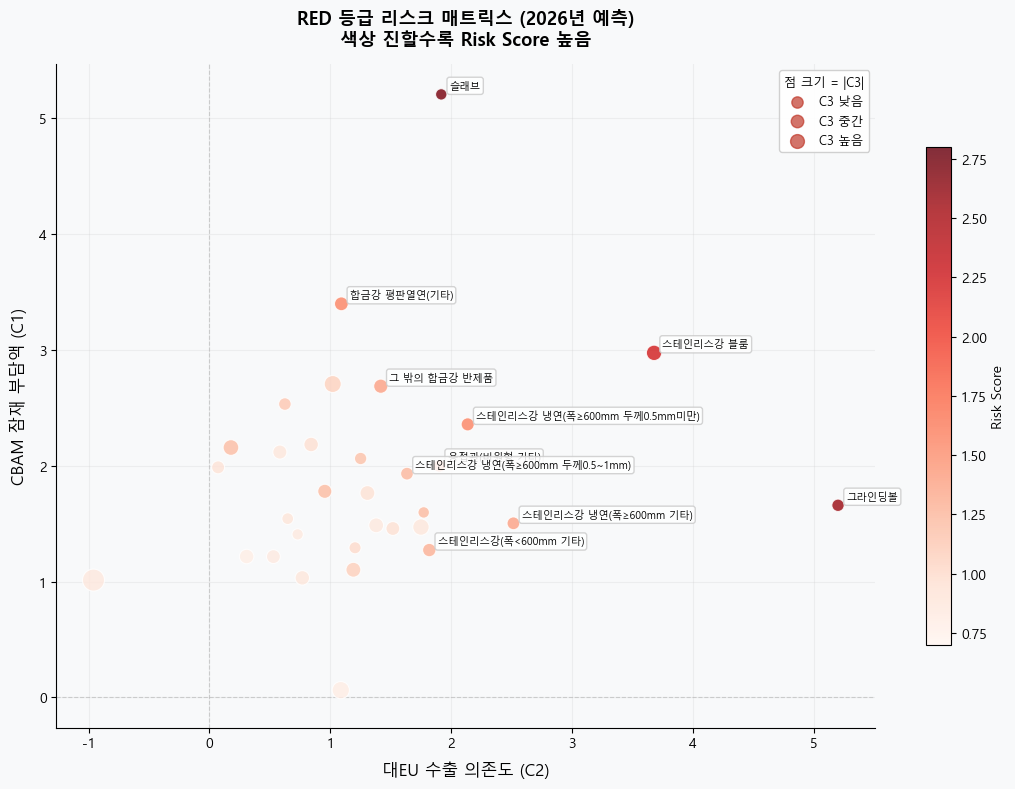

저장: fig_red_matrix.png


In [5]:
fig, ax = plt.subplots(figsize=(11, 8))
fig.patch.set_facecolor(BG); ax.set_facecolor(BG)

size = (red['c3_scaled_pred'].abs() * 60 + 60).clip(40, 350)

sc = ax.scatter(
    red['c2_scaled_pred'], red['c1_scaled_pred'],
    s=size, c=red['Risk_Score'],
    cmap='Reds', vmin=0.7, vmax=2.8,
    alpha=0.82, edgecolors='white', linewidth=0.8, zorder=3
)

cbar = plt.colorbar(sc, ax=ax, shrink=0.75)
cbar.set_label('Risk Score', fontsize=10)

for _, row in red.head(10).iterrows():
    ax.annotate(
        row['hs6_name_kr'],
        xy=(row['c2_scaled_pred'], row['c1_scaled_pred']),
        xytext=(6, 4), textcoords='offset points', fontsize=7.5,
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='#CCCCCC', alpha=0.85)
    )

ax.axhline(0, color='#AAAAAA', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axvline(0, color='#AAAAAA', linestyle='--', linewidth=0.8, alpha=0.5)

for c3v, lbl in [(0.1, 'C3 낮음'), (0.35, 'C3 중간'), (0.65, 'C3 높음')]:
    ax.scatter([], [], s=c3v*60+60, c='#C0392B', alpha=0.7, label=lbl)
ax.legend(title='점 크기 = |C3|', fontsize=9, title_fontsize=9, framealpha=0.9)

ax.set_xlabel('대EU 수출 의존도 (C2)', fontsize=12, labelpad=8)
ax.set_ylabel('CBAM 잠재 부담액 (C1)', fontsize=12, labelpad=8)
ax.set_title('RED 등급 리스크 매트릭스 (2026년 예측)\n색상 진할수록 Risk Score 높음',
             fontsize=13, fontweight='bold', pad=14)
ax.grid(True, alpha=0.25, color='#CCCCCC')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../csv/processed/fig_red_matrix.png', dpi=160, bbox_inches='tight')
plt.show()
print('저장: fig_red_matrix.png')

---
## 4. 카테고리별 리스크 등급 분포

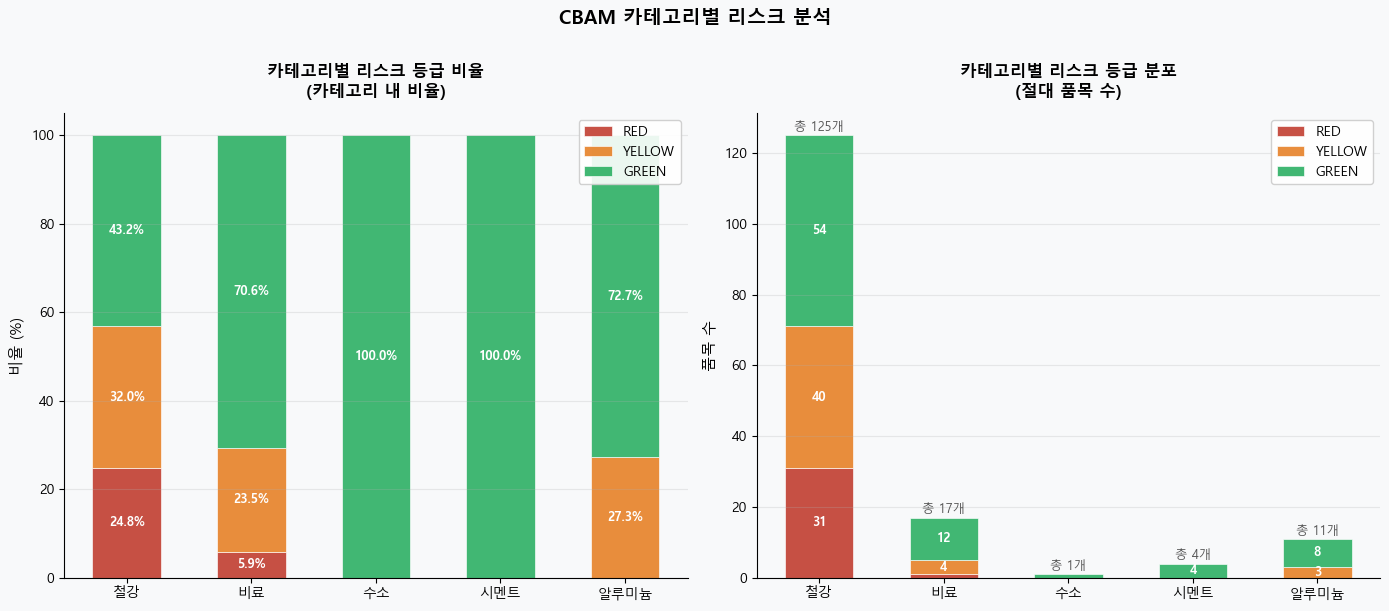

저장: fig_category.png


In [6]:
cat_grade  = final.groupby(['cbam_category', 'Risk_Grade']).size().unstack(fill_value=0)
cat_total  = cat_grade.sum(axis=1)
cat_ratio  = (cat_grade.div(cat_total, axis=0) * 100).round(1)
cat_order  = cat_ratio['RED'].sort_values(ascending=False).index
cat_ratio  = cat_ratio.reindex(cat_order)
cat_grade2 = cat_grade.reindex(cat_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(BG)

for ax, use_ratio, title, ylabel in [
    (axes[0], True,  '카테고리별 리스크 등급 비율\n(카테고리 내 비율)',  '비율 (%)'),
    (axes[1], False, '카테고리별 리스크 등급 분포\n(절대 품목 수)', '품목 수'),
]:
    data_use = cat_ratio if use_ratio else cat_grade2
    bottom = np.zeros(len(data_use))
    for grade in ['RED', 'YELLOW', 'GREEN']:
        if grade not in data_use.columns: continue
        vals = data_use[grade]
        ax.bar(data_use.index, vals, bottom=bottom,
               color=grade_colors[grade], alpha=0.88, label=grade,
               width=0.55, edgecolor='white', linewidth=0.5)
        for i, (v, b) in enumerate(zip(vals, bottom)):
            if v > (3 if use_ratio else 1):
                ax.text(i, b + v/2, f'{v:.1f}%' if use_ratio else str(int(v)),
                        ha='center', va='center', fontsize=9, color='white', fontweight='bold')
        bottom += vals.values

    if not use_ratio:
        for i, total in enumerate(cat_total.reindex(cat_order)):
            ax.text(i, total + 1.2, f'총 {total}개', ha='center', fontsize=9, color='#555')

    ax.set_title(title, fontsize=12, fontweight='bold', pad=12)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.legend(fontsize=10, framealpha=0.9)
    ax.grid(True, axis='y', alpha=0.25)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_facecolor(BG)

plt.suptitle('CBAM 카테고리별 리스크 분석', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../csv/processed/fig_category.png', dpi=160, bbox_inches='tight')
plt.show()
print('저장: fig_category.png')

---
## 5. 주요 리스크 요인 분석

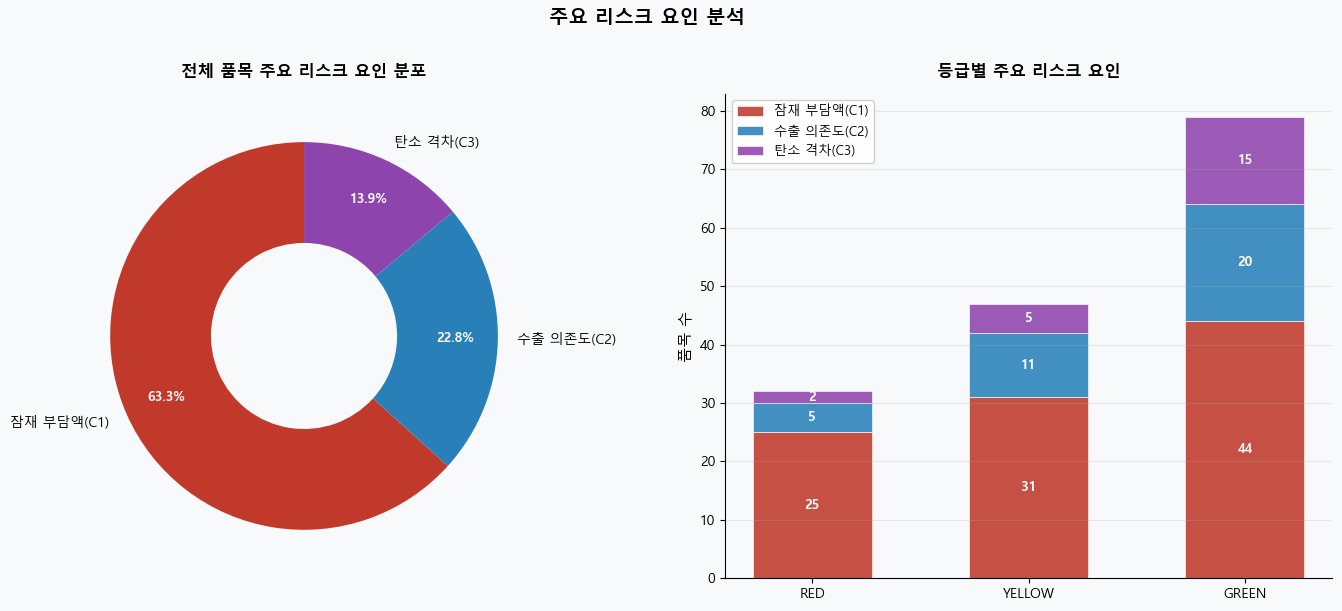

저장: fig_factor.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(BG)

# 도넛
factor_counts = final['Main_Risk_Factor'].value_counts()
colors_pie = [factor_colors[f] for f in factor_counts.index]
wedges, texts, autotexts = axes[0].pie(
    factor_counts, labels=factor_counts.index, colors=colors_pie,
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(width=0.52), pctdistance=0.78,
    textprops={'fontsize': 10}
)
for at in autotexts:
    at.set_fontsize(9.5); at.set_fontweight('bold'); at.set_color('white')
axes[0].set_title('전체 품목 주요 리스크 요인 분포', fontsize=12, fontweight='bold', pad=12)
axes[0].set_facecolor(BG)

# 등급별 누적 바
grade_factor = final.groupby(['Risk_Grade', 'Main_Risk_Factor']).size().unstack(fill_value=0)
grade_factor = grade_factor.reindex(['RED', 'YELLOW', 'GREEN'])

bottom = np.zeros(3)
for factor in ['잠재 부담액(C1)', '수출 의존도(C2)', '탄소 격차(C3)']:
    if factor not in grade_factor.columns: continue
    vals = grade_factor[factor]
    axes[1].bar(['RED', 'YELLOW', 'GREEN'], vals, bottom=bottom,
                color=factor_colors[factor], alpha=0.88, label=factor,
                width=0.55, edgecolor='white', linewidth=0.5)
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 1:
            axes[1].text(i, b + v/2, str(int(v)),
                         ha='center', va='center', fontsize=9.5, color='white', fontweight='bold')
    bottom += vals.values

axes[1].set_title('등급별 주요 리스크 요인', fontsize=12, fontweight='bold', pad=12)
axes[1].set_ylabel('품목 수', fontsize=11)
axes[1].legend(fontsize=9.5, framealpha=0.9)
axes[1].grid(True, axis='y', alpha=0.25)
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].set_facecolor(BG)

plt.suptitle('주요 리스크 요인 분석', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../csv/processed/fig_factor.png', dpi=160, bbox_inches='tight')
plt.show()
print('저장: fig_factor.png')